# 样条基函数与变系数模型：Stata 实操

> **课程**：部分线性函数型面板数据模型 (PLFC)
> 
> **数据来源**：Du et al. (2021), Energy Economics
> 
> **目标**：理解样条基函数如何逼近未知的函数系数 γ(U)

---

## 数据准备

使用 Du et al. (2021) 的中国城市面板数据。

In [ ]:
*----- 载入数据
use "https://github.com/lianxhcn/data/raw/refs/heads/main/stata/Du2021EE_ERdata.dta", clear

*----- 设定面板结构
xtset cityno year

(Du et al. (2021, EE) https://doi.org/10.1016/j.eneco.2021.105247)

Panel variable: cityno (strongly balanced)
 Time variable: year, 2002 to 2015
         Delta: 1 unit


In [124]:
*----- 查看主要变量
describe gti er gdp rd pop hc inv fdi


Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
gti             int     %10.0g                Green technology patents
                                                (authorized, by application
                                                date)
er              double  %10.0g                ER: environmental regulation
                                                index (entropy-weight
                                                composite)
gdp             double  %10.0g                Real GDP per capita (2001
                                                constant prices)
rd              double  %10.0g                Fiscal exp. on tech & education /
                                                GDP
pop             double  %10.0g                Population (10,000 persons)
hc              double  %10.0g                High school students (1

In [10]:
*----- 描述性统计
tabstat lngti er lngdp lnrd lnpop lnhc lninv lnfdi, ///
        f(%4.2f) s(n mean sd min max) c(s) 


    Variable |         N      Mean        SD       Min       Max
-------------+--------------------------------------------------
       lngti |   1470.00      4.32      1.89      0.00      9.53
          er |   1470.00      0.08      0.04      0.02      0.45
       lngdp |   1470.00     10.09      0.67      8.12     11.76
        lnrd |   1470.00     -0.06      0.61     -1.84      1.65
       lnpop |   1470.00      6.11      0.72      3.31      8.01
        lnhc |   1470.00      4.29      1.36     -0.27      6.95
       lninv |   1470.00      3.95      0.42      2.46      5.10
       lnfdi |   1470.00      0.47      1.19     -6.01      3.00
----------------------------------------------------------------


**变量说明**：
- `lngti`: 绿色技术创新（对数）
- `er`: 环境规制强度
- `lngdp`: 人均 GDP（对数）—— 调节变量 U
- `lnrd`: 科技与教育经费投入
- `lnpop`: 城市规模
- `lnhc`: 人力资本
- `lninv`: 固定资产投资
- `lnfdi`: 经济开放度

## 手动构造样条基函数

为了深入理解 `xtplfc` 的工作原理，我们先手动构造三次样条基函数。

### Step 1: 确定样条结点位置

选择 lngdp 的 30% 和 60% 分位点作为结点。

In [1]:
use "https://github.com/lianxhcn/data/raw/refs/heads/main/stata/Du2021EE_ERdata.dta", clear

*----- 计算分位点作为结点
_pctile lngdp, p(30 60)
global knot1: dis %6.3f r(r1) 
global knot2: dis %6.3f r(r2) 

display "Knot 1 (30th percentile): " $knot1
display "Knot 2 (60th percentile): " $knot2


Running D:\stata19/profile.do ...


(Du et al. (2021, EE) https://doi.org/10.1016/j.eneco.2021.105247)
Knot 1 (30th percentile): 9.716
Knot 2 (60th percentile): 10.281


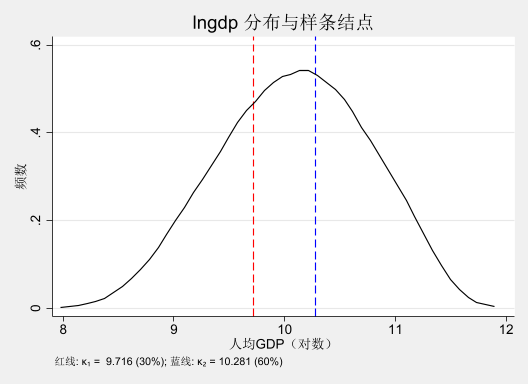

In [2]:
*----- 可视化结点位置
kdensity lngdp, ///
    xline($knot1, lcolor(red)  lpattern(dash)) ///
    xline($knot2, lcolor(blue) lpattern(dash)) ///
    xtitle("人均GDP（对数）") ///
    ytitle("频数") ///
    title("lngdp 分布与样条结点") ///
    note("红线: κ₁ = $knot1 (30%); 蓝线: κ₂ = $knot2 (60%)") ///
    scheme(s2mono)

### 2.2 Step 2: 构造三次样条基函数

构造 6 个基函数：
- h1 = 1 (常数项)
- h2 = U (线性项)
- h3 = U² (二次项)
- h4 = U³ (三次项)
- h5 = (U - κ₁)³₊ (第一个样条调整项)
- h6 = (U - κ₂)³₊ (第二个样条调整项)

In [3]:
*----- 基函数 h1 到 h4：多项式项
*gen h1 = 1    // Stata 会自动加入常数项，因此不需要这一项
gen h2 = lngdp
gen h3 = lngdp^2
gen h4 = lngdp^3

*----- 基函数 h5 和 h6：样条调整项（截断幂函数）
gen h5 = (lngdp - $knot1)^3 if lngdp > $knot1
replace h5 = 0 if lngdp <= $knot1

gen h6 = (lngdp - $knot2)^3 if lngdp > $knot2
replace h6 = 0 if lngdp <= $knot2

(441 missing values generated)
(441 real changes made)
(884 missing values generated)
(884 real changes made)


In [129]:
*----- 检查基函数的分布
summarize h2-h6


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
          h2 |      1,470    10.08827    .6711921   8.116106   11.75655
          h3 |      1,470    102.2234    13.49979   65.87118   138.2164
          h4 |      1,470    1040.305    204.7095   534.6175   1624.947
          h5 |      1,470    .5914555    1.111614          0   8.496483
          h6 |      1,470    .1070663     .308674          0   3.212612


### Step 3: 构造交互项 (Z × h)

将环境规制（er）与每个基函数相乘，得到 6 个交互项。

**核心思想**：原模型 $Y=\gamma(U) Z+\beta X+\alpha$ ，其中 $\gamma(U) \approx \sum \theta_j {\color{blue}{h_j(U)}}$

因此，

$$Y \approx \sum \theta_j\left[Z \cdot {\color{blue}{h_j(U)}}\right]+\beta X+\alpha$$

即 $Z \cdot {\color{blue}{h_j(U)}}$ 成为新的解释变量。

In [4]:
*----- 构造交互项（从 h2 开始，以防止完全共线性）
forvalues j = 2/6 {
    gen h`j'_er = h`j' * er
}

ds h*_er

h2_er  h3_er  h4_er  h5_er  h6_er



## 估计模型（手动方法）

使用 `reghdfe` 吸收城市固定效应，等价于先一阶差分再 OLS。

In [ ]:
*----- 安装 reghdfe（如未安装）
* ssc install reghdfe, replace

In [5]:
*----- 估计模型
reghdfe lngti h2_er h3_er h4_er h5_er h6_er ///
        lnrd lnpop lnhc lninv lnfdi, ///
        absorb(cityno) vce(cluster cityno)

est store manual_est  // 存结果

(MWFE estimator converged in 1 iterations)

HDFE Linear regression                            Number of obs   =      1,470
Absorbing 1 HDFE group                            F(  10,    104) =     138.27
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.9354
                                                  Adj R-squared   =     0.9299
                                                  Within R-sq.    =     0.8211
Number of clusters (cityno)  =        105         Root MSE        =     0.4998

                               (Std. err. adjusted for 105 clusters in cityno)
------------------------------------------------------------------------------
             |               Robust
       lngti | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       h2_er |   -111.508     35.145    -3.17   0.

**结果解读**：
- `h2_er` 到 `h6_er` 的系数即为 $\theta_2$ 到 $\theta_6$
- 这些系数本身不直接解释，需要组合成 $\gamma(U)$


## 计算边际效应 γ(U)

由于模型中包含了拐点项，即 $(U - \kappa_k)^3_+$，我们无法使用 `margins` 命令计算边际效应。此时，需要借助 `predictnl` 命令来计算每个观测点的边际效应，即 

$$\hat{\gamma}(U_i) = \sum_{j=2}^{6} \hat{\theta}_j h_j(U_i)$$

标准误可以使用 `predictnl` 的 `se()` 选项计算，详情参见 [**[R]** predictnl](https://www.stata.com/manuals/rpredictnl.pdf)。

In [7]:
*----- 计算 γ̂(U) = θ̂₂h₂(U) + θ̂₃h₃(U) + ... + θ̂₆h₆(U)
cap drop gamma_hat 
cap drop gamma_se
predictnl gamma_hat = _b[h2_er] * lngdp ///
                    + _b[h3_er] * lngdp^2 ///
                    + _b[h4_er] * lngdp^3 ///
                    + _b[h5_er] * max(lngdp - $knot1, 0)^3 ///
                    + _b[h6_er] * max(lngdp - $knot2, 0)^3, ///
                    se(gamma_se)

*----- 构造 95% 置信区间
gen gamma_lb = gamma_hat - 1.96 * gamma_se
gen gamma_ub = gamma_hat + 1.96 * gamma_se

label var gamma_hat "ER 对 GTI 的边际效应"
label var gamma_lb "95% CI 下界"
label var gamma_ub "95% CI 上界"

In [8]:
*----- 查看边际效应的分布
summarize gamma_hat gamma_se gamma_lb gamma_ub


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
   gamma_hat |      1,470   -.9434624     7.80896  -40.47254   9.881587
    gamma_se |      1,470    1.705248    .9714625   1.120716   9.403664
    gamma_lb |      1,470   -4.285748    9.511348  -58.90372   6.931313
    gamma_ub |      1,470    2.398824    6.224541  -22.04136    13.4857




## 结果可视化

### 基本散点图 + 置信区间

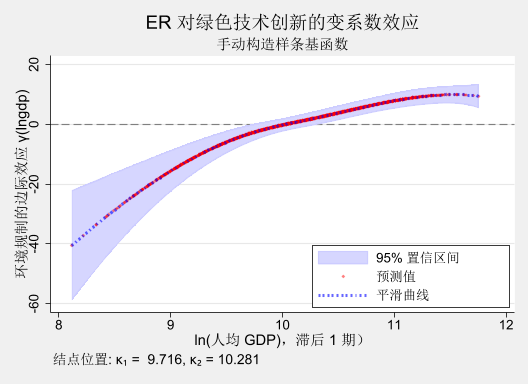

In [9]:
*----- 绘制边际效应曲线
twoway (rarea gamma_lb gamma_ub lngdp, color(blue*0.2) sort) ///
       (scatter gamma_hat lngdp, msize(tiny) mcolor(red%30)) ///
       (lpoly gamma_hat lngdp, lcolor(blue%60) lwidth(thick) degree(3)), ///
       yline(0, lcolor(gray) lp(dash)) ///
       xtitle("ln(人均 GDP)，滞后 1 期）", size(medium)) ///
       ytitle("环境规制的边际效应 γ(lngdp)", size(medium)) ///
       title("ER 对绿色技术创新的变系数效应", size(large)) ///
       subtitle("手动构造样条基函数", size(medium)) ///
       legend(order(1 "95% 置信区间" 2 "预测值" 3 "平滑曲线") ///
              ring(0) pos(5) cols(1)) ///
       note("结点位置: κ₁ = $knot1, κ₂ = $knot2", size(*1.3)) ///
       scheme(s2mono)

[原文](https://file.lianxh.cn/Refs/refs_common/Du_2021_EE_xtplfc.pdf) 结果：

<img src="https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/20260125170333.png" width="600" alt="20260125170333">


### 分段绘制（展示样条的分段特性）

(Note: Below code run with echo to enable preserve/restore functionality.)



(1,016 missing values generated)

(438 real changes made)

(578 real changes made)








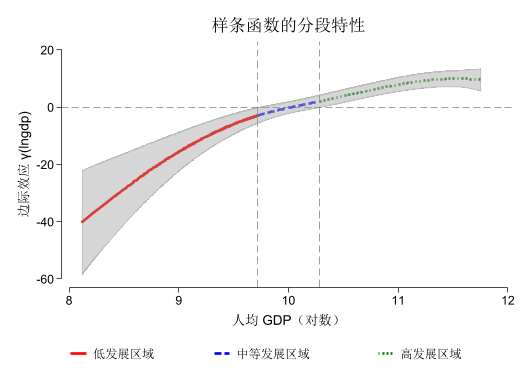

In [11]:
*----- 创建临时数据用于分段绘图
preserve
    collapse (mean) gamma_hat gamma_lb gamma_ub, by(lngdp)
    
    *----- 定义发展水平分组
    gen region = 1 if lngdp <= $knot1
    replace region = 2 if lngdp > $knot1 & lngdp <= $knot2
    replace region = 3 if lngdp > $knot2
    
    label define region_lab 1 "低发展水平" 2 "中等发展水平" 3 "高发展水平"
    label values region region_lab
    
    *----- 分段绘图
    twoway (line gamma_hat lngdp if region==1, lw(*2.5) lc(red)   ) ///
           (line gamma_hat lngdp if region==2, lw(*2.5) lc(blue)) ///
           (line gamma_hat lngdp if region==3, lw(*2.5) lc(green) ) ///
           (rarea gamma_lb gamma_ub lngdp, color(black*0.5%40)), ///
           yline(0, lc(black*0.6) lp(dash) lw(*0.6)) ///
           xline($knot1 $knot2, lcolor(black*0.6) lp(dash) lw(*0.6)) ///
           xtitle("人均 GDP（对数）") ///
           ytitle("边际效应 γ(lngdp)") ///
           title("样条函数的分段特性") ///
           legend(order(1 "低发展区域" 2 "中等发展区域" 3 "高发展区域") ///
                  pos(5) r(1) ) ///
           scheme(scientific)
restore


## 使用 xtplfc 命令

现在我们使用 `xtplfc` 命令重新估计，并与手动结果对比。

In [ ]:
*----- 安装 xtplfc（如未安装）
* net install st0624.pkg, all replace from(http://www.stata-journal.com/software/sj20-4)

### 模型设定

由前文介绍可知，函数系数模型的一般形式为：

$$Y = \gamma(U) Z + \beta X + \alpha + \epsilon$$

我们关心的是 $Z$ 对 $Y$ 的边际影响 $\gamma(U)$，尤其是 $\gamma(U)$ 随调节变量 $U$ 的变化情况。

Du et al. (2021) 中的模型设定为：

$$lngti_{it} = \gamma(lngdp_{it-1}) er_{it} + \beta X_{it} + \alpha_i + \epsilon_{it}$$

对应关系为：$Y = lngti_{it}$，$U = lngdp_{it-1}$，$Z = er_{it}$


In [149]:
*----- 使用 xtplfc 估计
cap drop fcoe_gti*  
local controls "lnrd lnpop lnhc lninv lnfdi"
xtplfc lngti `controls', ///
       zvars(er) ///
       uvar(lngdp) ///
       gen(fcoe_gti) ///
       power(3)  nknots(2)  quantile ///          
       brep(200)


Computing the bootstrap standard errors...
.................................................50
.................................................100
.................................................150
.................................................200

Partially linear functional-coefficient panel data model.
Fixed-effect series semiparametric estimation.
Estimation results: linear part                 Number of obs        =    1365
                                                Within R-squared     =  0.1754
                                                Adj Within R-squared =  0.1693
                                                Root MSE             =  0.4291
------------------------------------------------------------------------------
       lngti | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        lnrd |      0.089      0.048     1.84   0.066       -0.006       0.184
       

**注**：上述命令中的关键选项说明如下：

- `gen(fcoe_gti)`：指定变量名前缀，用于存储  及其标准误。程序会自动生成以下变量：
  - `fcoe_gti_1`：$\gamma(U)$ 的估计值 $\hat{\gamma}(U)$
  - `fcoe_gti_1_sd`：$\gamma(U)$ 的标准误 $se(\hat{\gamma}(U))$（通过 Bootstrap 得到）
- `brep(200)`：指定 Bootstrap 重抽样次数为 200 次，以估计 $\hat{\gamma}(U)$ 的标准误 (后面绘图时会用到)。
  - 本例中为了节省运行时间，将抽样次数设为 200，实际应用时建议设为 1000 次或更多。

In [150]:
*----- 构造置信区间
gen fcoe_lb = fcoe_gti_1 - 1.96 * fcoe_gti_1_sd
gen fcoe_ub = fcoe_gti_1 + 1.96 * fcoe_gti_1_sd

### 对比两种方法的结果

In [151]:
*----- 计算相关系数
correlate gamma_hat fcoe_gti_1

(obs=1,470)

             | gamma_~t fcoe_g~1
-------------+------------------
   gamma_hat |   1.0000
  fcoe_gti_1 |   0.9843   1.0000



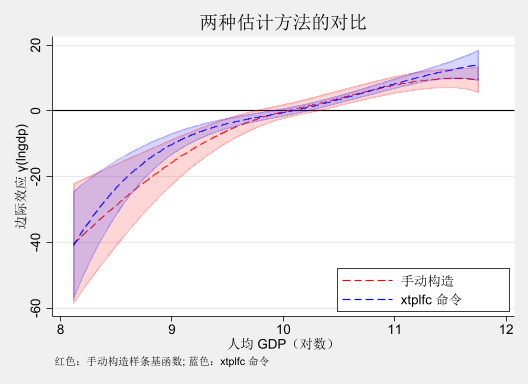

In [153]:
*----- 绘制对比图
twoway (rarea gamma_lb gamma_ub lngdp, color(red%20) sort) ///
       (line gamma_hat lngdp, lcolor(red) lwidth(medium) sort) ///
       (rarea fcoe_lb fcoe_ub lngdp, color(blue%20) sort) ///
       (line fcoe_gti_1 lngdp, lcolor(blue) lwidth(medium) lpattern(dash) sort), ///
       yline(0, lcolor(black)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       title("两种估计方法的对比") ///
       legend(order(2 "手动构造" 4 "xtplfc 命令") ///
              ring(0) pos(5) c(1)) ///
       note("红色：手动构造样条基函数; 蓝色：xtplfc 命令") ///
       scheme(s2mono)


## 稳健性检验

有些读者可能会担心，样条基函数的选择（如结点位置、次数等）会不会对结果产生较大影响。为此，我们可以尝试不同的结点位置和次数，观察估计结果的稳定性。

对比结果显示，无论是改变节点数 (使用 3 个节点和 4 个节点)，还是改变次数 (使用二次和三次样条)，得到的结果与上文基本设定下的结果都不存在显著差异。这说明，估计结果对样条基函数的选择较为稳健。这也是样条方法的一个重要优点。

### 改变结点数量

In [62]:
*----- 使用 3 个结点（25%, 50%, 75% 分位点）
cap drop fcoe_3knots*
xtplfc lngti lnrd lnpop lnhc lninv lnfdi, ///
       zvars(er) uvar(lngdp) ///
       gen(fcoe_3knots) ///
       nknots(3) quantile brep(10)


Computing the bootstrap standard errors...
..........
Partially linear functional-coefficient panel data model.
Fixed-effect series semiparametric estimation.
Estimation results: linear part                 Number of obs        =    1365
                                                Within R-squared     =  0.1749
                                                Adj Within R-squared =  0.1682
                                                Root MSE             =  0.4294
------------------------------------------------------------------------------
       lngti | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        lnrd |      0.088      0.025     3.51   0.000        0.039       0.138
       lnpop |      1.630      0.271     6.01   0.000        1.098       2.163
        lnhc |      0.217      0.080     2.73   0.006        0.061       0.373
       lninv |      0.396      0.102     3.89   0.

In [64]:
*----- 使用 4 个结点
cap drop fcoe_4knots*
xtplfc lngti lnrd lnpop lnhc lninv lnfdi, ///
       zvars(er) uvar(lngdp) ///
       gen(fcoe_4knots) ///
       nknots(4) quantile brep(100)


Computing the bootstrap standard errors...
.................................................50
.................................................100

Partially linear functional-coefficient panel data model.
Fixed-effect series semiparametric estimation.
Estimation results: linear part                 Number of obs        =    1365
                                                Within R-squared     =  0.1771
                                                Adj Within R-squared =  0.1698
                                                Root MSE             =  0.4289
------------------------------------------------------------------------------
       lngti | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        lnrd |      0.090      0.047     1.93   0.054       -0.001       0.182
       lnpop |      1.670      0.267     6.26   0.000        1.147       2.193
        lnhc |      0.210      0.0

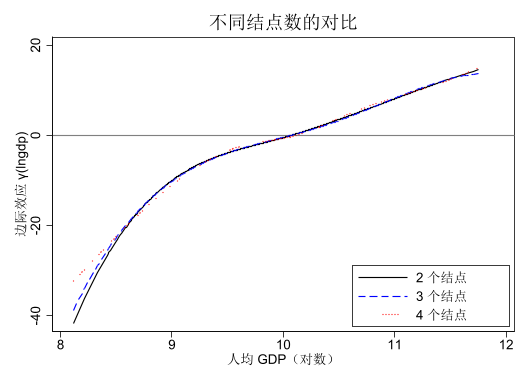

In [ ]:
*----- 对比不同结点数的结果
twoway (line fcoe_gti_1    lngdp, lc(black) lwidth(medium) sort) ///
       (line fcoe_3knots_1 lngdp, lc(blue)  lpattern(dash) sort) ///
       (line fcoe_4knots_1 lngdp, lc(red)   lpattern(dot) sort), ///
       yline(0, lcolor(gray)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       title("不同结点数的对比") ///
       legend(order(1 "2 个结点" 2 "3 个结点" 3 "4 个结点") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

### 使用不同的样条类型

In [155]:
*----- 二次样条
xtplfc lngti lnrd lnpop lnhc lninv lnfdi, ///
       zvars(er) uvar(lngdp) ///
       gen(fcoe_quad) ///
       power(2) nknots(2) quantile brep(100)


Computing the bootstrap standard errors...
.................................................50
.................................................100

Partially linear functional-coefficient panel data model.
Fixed-effect series semiparametric estimation.
Estimation results: linear part                 Number of obs        =    1365
                                                Within R-squared     =  0.1726
                                                Adj Within R-squared =  0.1671
                                                Root MSE             =  0.4297
------------------------------------------------------------------------------
       lngti | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        lnrd |      0.086      0.055     1.57   0.116       -0.021       0.194
       lnpop |      1.604      0.235     6.82   0.000        1.143       2.065
        lnhc |      0.227      0.0

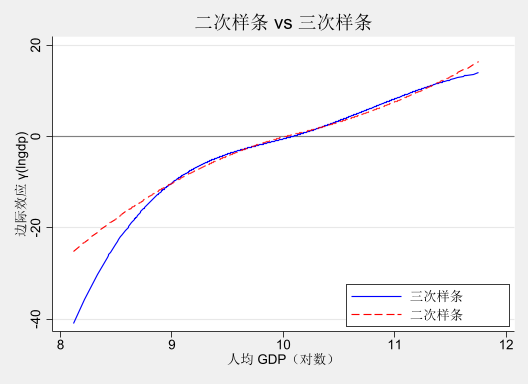

In [156]:
*----- 对比二次样条和三次样条
twoway (line fcoe_gti_1 lngdp, lcolor(blue) lwidth(medium) sort) ///
       (line fcoe_quad_1 lngdp, lcolor(red) lpattern(dash) sort), ///
       yline(0, lcolor(gray)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       title("二次样条 vs 三次样条") ///
       legend(order(1 "三次样条" 2 "二次样条") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

## 结果解释示例

### 如何解读边际效应曲线？

**横轴（lngdp）**：
- 城市的经济发展水平（人均 GDP 的对数）
- 范围通常在 8-12 之间

**纵轴（γ(lngdp)）**：
- ER 对 GTI 的边际效应
- 正值：ER 促进 GTI
- 负值：ER 抑制 GTI
- 接近 0：ER 无显著影响

**置信区间（灰色阴影）**：
- 包含 0：边际效应不显著
- 不包含 0：边际效应显著

**典型模式**：
1. **lngdp < 9**：边际效应为负 → 经济欠发达地区，ER 抑制 GTI
2. **9 < lngdp < 10**：边际效应接近 0 → 过渡阶段
3. **lngdp > 10**：边际效应为正且增强 → 经济发达地区，ER 促进 GTI

In [157]:
*----- 生成显著性指示变量
gen significant = 0
replace significant = 1 if fcoe_lb > 0  // 显著为正
replace significant = -1 if fcoe_ub < 0 // 显著为负

label define sig_lab -1 "显著为负" 0 "不显著" 1 "显著为正"
label values significant sig_lab

(630 real changes made)
(557 real changes made)


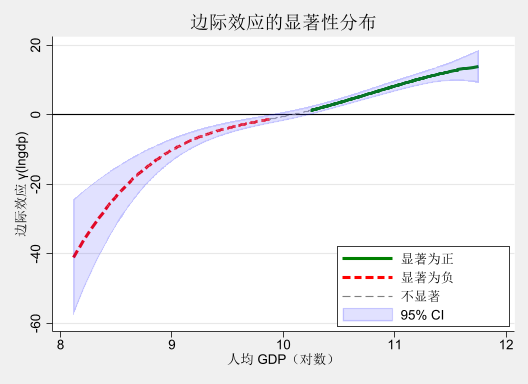

In [161]:
*----- 按显著性分段绘图
twoway (line fcoe_gti_1 lngdp if significant==1, lcolor(green) lwidth(thick) sort) ///
       (line fcoe_gti_1 lngdp if significant==-1, lcolor(red) lwidth(thick) sort) ///
       (line fcoe_gti_1 lngdp if significant==0, lcolor(gray) lpattern(dash) sort) ///
       (rarea fcoe_lb fcoe_ub lngdp, color(blue%15) sort), ///
       yline(0, lcolor(black)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       title("边际效应的显著性分布") ///
       legend(order(1 "显著为正" 2 "显著为负" 3 "不显著" 4 "95% CI") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

In [162]:
*----- 统计不同显著性区间的样本比例
tab significant, missing


significant |      Freq.     Percent        Cum.
------------+-----------------------------------
   显著为负 |        557       37.89       37.89
     不显著 |        283       19.25       57.14
   显著为正 |        630       42.86      100.00
------------+-----------------------------------
      Total |      1,470      100.00
